In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import  train_test_split
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout
import keras
import tensorflow as tf
from src import *
from tensorflow.keras.callbacks import EarlyStopping


# Configurações 
print(tf.config.list_physical_devices())
BATCH_SIZE = 4096

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# **Classificação para 3 classes**

#### Função para encontrar o número máximo de neurônio

In [3]:
def num_max_neuronio(X, d):
    CT = len(X)
    return int((CT - 10)/(10 * (d + 2)))

#### Leitura dos dados e adaptações necessárias para a rede neural 

In [4]:
colunas = (
        [f'questao_{i}_LC' for i in range(1, 46)] +
        [f'questao_{i}_CH' for i in range(1, 46)] +
        [f'questao_{i}_CN' for i in range(1, 46)] +
        [f'questao_{i}_MT' for i in range(1, 46)] +
        ['NU_ANO', 'NU_NOTA_LC', 'NU_NOTA_CH', 'NU_NOTA_CN', 'NU_NOTA_MT']
    )
df = pd.read_parquet('data/dados acertos/')

In [5]:
df = calcular_acertos_por_area(df)

In [6]:
df['MEDIA_GERAL'] = (
    df['ACERTOS_LC'] + 
    df['ACERTOS_MT'] + 
    df['ACERTOS_CH'] + 
    df['ACERTOS_CN']
) / 4

df['CLASSE'] = df.groupby('NU_ANO')['MEDIA_GERAL'].transform(
    lambda x: pd.qcut(x, q=3, labels=[0, 1, 2])
).astype('Int64')

df['CLASSE'] = df['CLASSE'].astype(int)

In [7]:
features = (
        [f'questao_{i}_LC' for i in range(1, 46)] +
        [f'questao_{i}_CH' for i in range(1, 46)] +
        [f'questao_{i}_CN' for i in range(1, 46)] +
        [f'questao_{i}_MT' for i in range(1, 46)] 
    )

X = df[features]
y = df['CLASSE']


#### Separando os dados

In [8]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

#### Normalizando os dados

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

x_train = scaler.fit_transform(x_train).astype(np.float32)
x_val   = scaler.transform(x_val).astype(np.float32)
x_test  = scaler.transform(x_test).astype(np.float32)

In [10]:
# Analisando os dados do rotulo de treinamento
print("Tipo:", y_train.dtype)
print("Valores únicos:", np.unique(y_train))
print("Amostra:", y_train[:10])

Tipo: int64
Valores únicos: [0 1 2]
Amostra: 5746145    1
3123285    0
2370770    2
1514602    2
1213255    0
4628834    1
216790     1
2065521    0
2661903    2
4442373    1
Name: CLASSE, dtype: int64


#### Construindo a rede neural

In [23]:
max_neurons = num_max_neuronio(x_train, d = X.shape[1])
print("Número máximo de neurônios:", max_neurons)

Número máximo de neurônios: 4765


#### Rede com **1** camada 

In [11]:
model_1 = Sequential()

model_1.add(Input(shape=(x_train.shape[1],)))

model_1.add(Dense(4762, kernel_initializer='normal', activation='relu'))

model_1.add(Dense(3, kernel_initializer='normal', activation='softmax'))

model_1.compile(loss='sparse_categorical_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', mode='min', patience=10, verbose=1)

model_1.summary()

2026-03-25 18:09:11.617320: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-25 18:09:11.617949: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-25 18:09:11.618147: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-25 18:09:11.618403: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-25 18:09:11.618939: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4762)           │       861,922 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │        14,289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 876,211 (3.34 MB)

 Trainable params: 876,211 (3.34 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model_1.fit(
    x_train, y_train,
    epochs=5,
    batch_size= BATCH_SIZE,
    validation_data= (x_val, y_val),
    callbacks=[es],
    verbose=1
)

Epoch 1/5


2026-03-25 18:09:37.241322: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


2118/2118 ━━━━━━━━━━━━━━━━━━━━ 83s 38ms/step - accuracy: 0.8948 - loss: 0.2735 - val_accuracy: 0.9093 - val_loss: 0.2023
Epoch 2/5
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 80s 38ms/step - accuracy: 0.9132 - loss: 0.2013 - val_accuracy: 0.9099 - val_loss: 0.2064
Epoch 3/5
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 79s 37ms/step - accuracy: 0.9111 - loss: 0.2135 - val_accuracy: 0.9145 - val_loss: 0.2030
Epoch 4/5
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 79s 37ms/step - accuracy: 0.9088 - loss: 0.2260 - val_accuracy: 0.9146 - val_loss: 0.2031
Epoch 5/5
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 78s 37ms/step - accuracy: 0.9070 - loss: 0.2385 - val_accuracy: 0.9145 - val_loss: 0.2135


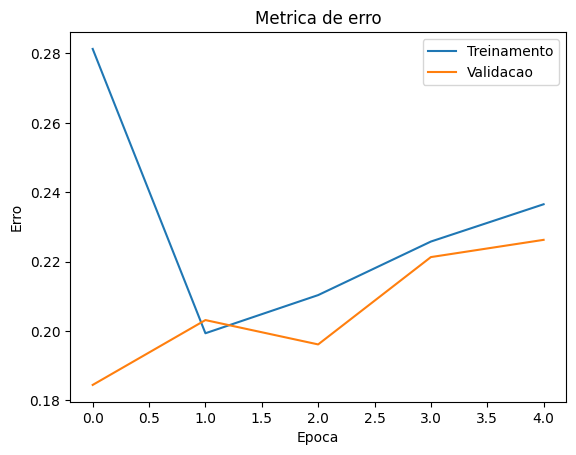

--> E_val - E_in = -0.0007
--> Acuracia (treino): 0.9086
--> Acuracia (validacao): 0.9088
--> acc_train - acc_val = -0.0002


In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Epoca')
plt.legend(['Treinamento', 'Validacao'])
plt.show()

# Obtendo a acuracia no conjunto de treinamento
E_in, acc_train = model_1.evaluate(x_train, y_train, batch_size=BATCH_SIZE, verbose=0)

# Obtendo a acuracia no conjunto de validacao
E_val, acc_val = model_1.evaluate(x_val, y_val, batch_size=BATCH_SIZE, verbose=0)

print(f"--> E_val - E_in = {E_val - E_in:.4f}")
print(f'--> Acuracia (treino): {acc_train:.4f}')
print(f'--> Acuracia (validacao): {acc_val:.4f}')
print(f"--> acc_train - acc_val = {acc_train - acc_val:.4f}")

#### Rede com 2 camadas

In [35]:
model = Sequential()
model.add(Input(shape=(x_train.shape[1],)))


model.add(Dense(2381,kernel_initializer='normal',activation='relu'))

# Dividi por 2 até que a quantidade de parametros * 10 seja menor que o número de amostras
model.add(Dense(148, kernel_initializer='normal', activation='relu'))

model.add(Dense(3, kernel_initializer='normal', activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', mode='min', patience=10, verbose=1)

model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 2381)           │       430,961 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 148)            │       352,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 3)              │           447 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 783,944 (2.99 MB)

 Trainable params: 783,944 (2.99 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size= BATCH_SIZE,
    validation_data= (x_val, y_val),
    callbacks=[es],
    verbose=1
)

Epoch 1/5
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 70s 32ms/step - accuracy: 0.8373 - loss: 0.6377 - val_accuracy: 0.7898 - val_loss: 1.9896
Epoch 2/5
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 67s 31ms/step - accuracy: 0.8404 - loss: 2.0177 - val_accuracy: 0.8713 - val_loss: 1.4618
Epoch 3/5
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 69s 33ms/step - accuracy: 0.8442 - loss: 4.0043 - val_accuracy: 0.7778 - val_loss: 11.8462
Epoch 4/5
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 68s 32ms/step - accuracy: 0.8441 - loss: 6.8713 - val_accuracy: 0.8629 - val_loss: 5.8013
Epoch 5/5
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 70s 33ms/step - accuracy: 0.8424 - loss: 10.3885 - val_accuracy: 0.9028 - val_loss: 3.1520


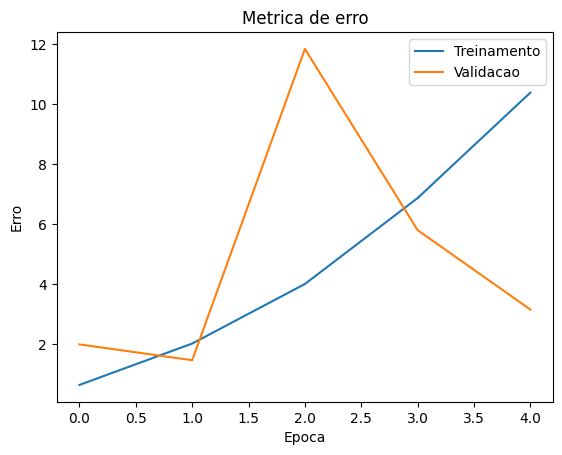

--> E_val - E_in = -0.0022
--> Acuracia (treino): 0.9027
--> Acuracia (validacao): 0.9028
--> acc_train - acc_val = -0.0001


In [37]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Epoca')
plt.legend(['Treinamento', 'Validacao'])
plt.show()

# Obtendo a acuracia no conjunto de treinamento
E_in, acc_train = model.evaluate(x_train, y_train, batch_size=BATCH_SIZE, verbose=0)

# Obtendo a acuracia no conjunto de validacao
E_val, acc_val = model.evaluate(x_val, y_val, batch_size=BATCH_SIZE, verbose=0)

print(f"--> E_val - E_in = {E_val - E_in:.4f}")
print(f'--> Acuracia (treino): {acc_train:.4f}')
print(f'--> Acuracia (validacao): {acc_val:.4f}')
print(f"--> acc_train - acc_val = {acc_train - acc_val:.4f}")

#### Rede forçando overfitting

In [40]:
model = Sequential()

model.add(Input(shape=(x_train.shape[1],)))

# Dobrando a quantidade de neurônios permitidos
model.add(Dense(9524, kernel_initializer='he_normal', activation='relu'))

model.add(Dense(3, kernel_initializer='he_normal', activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 9524)           │     1,723,844 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 3)              │        28,575 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,752,419 (6.68 MB)

 Trainable params: 1,752,419 (6.68 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size= BATCH_SIZE,
    validation_data= (x_val, y_val),
    verbose=1
)

Epoch 1/10
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 199s 93ms/step - accuracy: 0.8886 - loss: 0.2730 - val_accuracy: 0.9046 - val_loss: 0.2186
Epoch 2/10
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 190s 90ms/step - accuracy: 0.9105 - loss: 0.2119 - val_accuracy: 0.9139 - val_loss: 0.2054
Epoch 3/10
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 235s 111ms/step - accuracy: 0.9060 - loss: 0.2409 - val_accuracy: 0.9006 - val_loss: 0.2642
Epoch 4/10
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 186s 88ms/step - accuracy: 0.9034 - loss: 0.2671 - val_accuracy: 0.8951 - val_loss: 0.3230
Epoch 5/10
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 187s 88ms/step - accuracy: 0.8998 - loss: 0.3018 - val_accuracy: 0.8860 - val_loss: 0.3631
Epoch 6/10
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 170s 80ms/step - accuracy: 0.8968 - loss: 0.3419 - val_accuracy: 0.8958 - val_loss: 0.3927
Epoch 7/10
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 177s 83ms/step - accuracy: 0.8956 - loss: 0.3741 - val_accuracy: 0.9142 - val_loss: 0.2892
Epoch 8/10
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 233s 110ms/step - accuracy

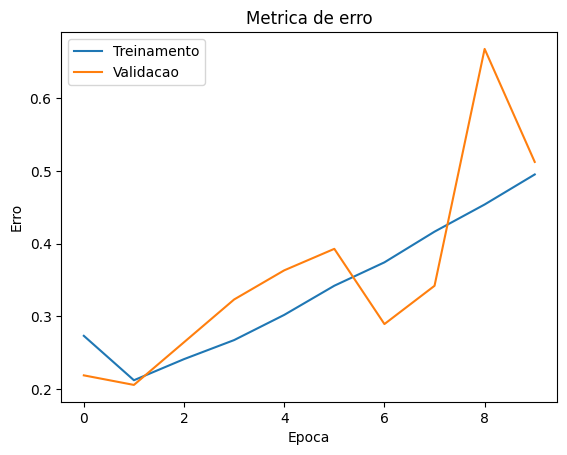

--> E_val - E_in = -0.0025
--> Acuracia (treino): 0.8859
--> Acuracia (validacao): 0.8862
--> acc_train - acc_val = -0.0003


In [42]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Epoca')
plt.legend(['Treinamento', 'Validacao'])
plt.show()

# Obtendo a acuracia no conjunto de treinamento
E_in, acc_train = model.evaluate(x_train, y_train, batch_size=BATCH_SIZE, verbose=0)

# Obtendo a acuracia no conjunto de validacao
E_val, acc_val = model.evaluate(x_val, y_val, batch_size=BATCH_SIZE, verbose=0)

print(f"--> E_val - E_in = {E_val - E_in:.4f}")
print(f'--> Acuracia (treino): {acc_train:.4f}')
print(f'--> Acuracia (validacao): {acc_val:.4f}')
print(f"--> acc_train - acc_val = {acc_train - acc_val:.4f}")

In [48]:
model = Sequential()
model.add(Input(shape=(x_train.shape[1],)))

model.add(Dense(4096, activation='relu'))
model.add(Dense(2048, activation='relu'))

model.add(Dense(3, activation='softmax'))

optimizer = keras.optimizers.Adam(learning_rate=0.00001)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                │ (None, 4096)           │       741,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 2048)           │     8,390,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,138,179 (34.86 MB)

 Trainable params: 9,138,179 (34.86 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size= BATCH_SIZE,
    validation_data= (x_val, y_val),
    verbose=1
)

Epoch 1/10
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 924s 435ms/step - accuracy: 0.7698 - loss: 0.5722 - val_accuracy: 0.9188 - val_loss: 0.2525
Epoch 2/10
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 388s 183ms/step - accuracy: 0.9197 - loss: 0.2087 - val_accuracy: 0.9214 - val_loss: 0.1905
Epoch 3/10
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 15792s 7s/step - accuracy: 0.9205 - loss: 0.1886 - val_accuracy: 0.9211 - val_loss: 0.1862
Epoch 4/10
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 424s 200ms/step - accuracy: 0.9203 - loss: 0.1871 - val_accuracy: 0.9208 - val_loss: 0.1848
Epoch 5/10
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 376s 178ms/step - accuracy: 0.9200 - loss: 0.1862 - val_accuracy: 0.9201 - val_loss: 0.1857
Epoch 6/10
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 401s 189ms/step - accuracy: 0.9198 - loss: 0.1856 - val_accuracy: 0.9206 - val_loss: 0.1848
Epoch 7/10
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 448s 211ms/step - accuracy: 0.9196 - loss: 0.1854 - val_accuracy: 0.9209 - val_loss: 0.1828
Epoch 8/10
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 496s 234ms/step - acc

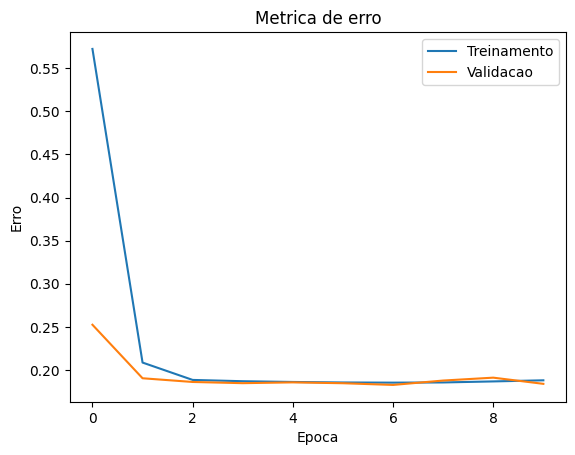

--> E_val - E_in = -0.0003
--> Acuracia (treino): 0.9208
--> Acuracia (validacao): 0.9210
--> acc_train - acc_val = -0.0002


In [50]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Epoca')
plt.legend(['Treinamento', 'Validacao'])
plt.show()

# Obtendo a acuracia no conjunto de treinamento
E_in, acc_train = model.evaluate(x_train, y_train, batch_size=BATCH_SIZE, verbose=0)

# Obtendo a acuracia no conjunto de validacao
E_val, acc_val = model.evaluate(x_val, y_val, batch_size=BATCH_SIZE, verbose=0)

print(f"--> E_val - E_in = {E_val - E_in:.4f}")
print(f'--> Acuracia (treino): {acc_train:.4f}')
print(f'--> Acuracia (validacao): {acc_val:.4f}')
print(f"--> acc_train - acc_val = {acc_train - acc_val:.4f}")

## **Aplicando no conjunto de teste**

In [14]:
# Rede neural que foi treinada com 1 camada respeitando a dimensão máxima de neurônios permitida
test_loss, test_acc = model_1.evaluate(x_test, y_test)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

84699/84699 ━━━━━━━━━━━━━━━━━━━━ 242s 3ms/step - accuracy: 0.9143 - loss: 0.2132
Test loss: 0.2131837010383606
Test accuracy: 0.9143407940864563
